# Pathspace Lab MVP

Pathspace Lab is a living tutorial for comparing three mechanisms on one layered path-DP problem:

- Hard DP as deterministic min-plus message passing.
- Soft-DP as a classical thermal distribution over complete paths.
- Feasible-subspace QA as coherent Hamiltonian evolution over feasible complete paths.

The heatmaps in this notebook will share a coordinate system, not a mechanism. DP values, Soft-DP probabilities, and QA amplitudes live in different hidden spaces and are only projected onto the same layer-node canvas for comparison.

In [1]:
from pathlib import Path
import sys

for candidate_root in (Path.cwd(), Path.cwd().parent):
    src_path = candidate_root / "src"
    if src_path.exists():
        sys.path.insert(0, str(src_path.resolve()))
        break

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pathspace_lab

print("Pathspace Lab import OK")
print(f"Pathspace Lab version: {pathspace_lab.__version__}")

Pathspace Lab import OK
Pathspace Lab version: 0.1.0


## Setup and Reproducibility

The notebook will grow issue by issue. Implementation logic belongs in `src/pathspace_lab`; notebook cells should import reusable package functions, display small diagnostics, and explain what each figure means.

Later sections are present now as placeholders so each future issue has a stable narrative home. Pending sections intentionally contain markdown only until their corresponding backend code exists.

In [2]:
component_status = pd.DataFrame(
    [
        {
            "Component": "Project package scaffold",
            "Status": "Implemented",
            "First issue": "00",
            "Notebook role": "Imports `pathspace_lab` from the package.",
        },
        {
            "Component": "Living notebook harness",
            "Status": "Implemented",
            "First issue": "00A",
            "Notebook role": "Provides the runnable tutorial skeleton.",
        },
        {
            "Component": "PathDPProblem protocol and traces",
            "Status": "Implemented",
            "First issue": "01",
            "Notebook role": "Demonstrate the shared data contract.",
        },
        {
            "Component": "LayeredDAGProblem",
            "Status": "Implemented",
            "First issue": "02",
            "Notebook role": "Create the first real layered path instance.",
        },
        {
            "Component": "Common observables",
            "Status": "Implemented",
            "First issue": "03",
            "Notebook role": "Measure path distributions and visible marginals.",
        },
        {
            "Component": "Hard DP",
            "Status": "Implemented",
            "First issue": "04",
            "Notebook role": "Show deterministic min-plus values and traceback.",
        },
        {
            "Component": "Soft-DP",
            "Status": "Implemented",
            "First issue": "05",
            "Notebook role": "Show thermal path probabilities and marginals.",
        },
        {
            "Component": "Feasible-subspace QA",
            "Status": "Pending",
            "First issue": "06-07",
            "Notebook role": "Show Hamiltonian objects and amplitude evolution.",
        },
        {
            "Component": "Visualizers",
            "Status": "Pending",
            "First issue": "08-11",
            "Notebook role": "Replace diagnostics with reusable figures.",
        },
    ]
)

component_status

,Component,Status,First issue,Notebook role
0,Project package scaffold,Implemented,00,Imports `pathspace_lab` from the package.
1,Living notebook harness,Implemented,00A,Provides the runnable tutorial skeleton.
2,PathDPProblem protocol and traces,Implemented,01,Demonstrate the shared data contract.
3,LayeredDAGProblem,Implemented,02,Create the first real layered path instance.
4,Common observables,Implemented,03,Measure path distributions and visible marginals.
5,Hard DP,Implemented,04,Show deterministic min-plus values and traceback.
6,Soft-DP,Pending,05,Show thermal path probabilities and marginals.
7,Feasible-subspace QA,Pending,06-07,Show Hamiltonian objects and amplitude evolution.
8,Visualizers,Pending,08-11,Replace diagnostics with reusable figures.


## Create a Planted Layered Path Problem

We now build the first real problem instance. A visible path chooses exactly one node per layer, so a problem with `L` layers and `W` choices per layer has `W ** L` feasible paths.

The generator plants two named paths. The gold path is globally optimal, but the decoy path has the cheaper early prefix and then pays a late transition penalty. That tension is deliberate: later probability plots can show how local attraction and global optimality separate.

In [3]:
from pathspace_lab.problems.layered_dag import make_planted_layered_problem

problem = make_planted_layered_problem(L=5, W=3, seed=7)
paths = problem.enumerate_paths()
energies = np.array([problem.path_energy(path) for path in paths])
best_index = int(energies.argmin())
best_path = paths[best_index]

gold_path = problem.metadata["gold_path"]
decoy_path = problem.metadata["decoy_path"]

print("num paths:", len(paths))
print("expected:", problem.W**problem.L)
print("best energy:", float(energies[best_index]))
print("best path:", best_path)
print("gold path:", gold_path)
print("decoy path:", decoy_path)
print("gold energy:", problem.metadata["gold_energy"])
print("decoy energy:", problem.metadata["decoy_energy"])
print("gold prefix energy:", problem.metadata["gold_prefix_energy"])
print("decoy prefix energy:", problem.metadata["decoy_prefix_energy"])

num paths: 243
expected: 243
best energy: 5.969999999999999
best path: ((0, 1), (1, 1), (2, 0), (3, 0), (4, 1))
gold path: ((0, 1), (1, 1), (2, 0), (3, 0), (4, 1))
decoy path: ((0, 2), (1, 2), (2, 1), (3, 1), (4, 2))
gold energy: 5.969999999999999
decoy energy: 8.46
gold prefix energy: 3.9100000000000006
decoy prefix energy: 1.21


In [4]:
problem_summary = pd.DataFrame(
    [
        {
            "quantity": "visible layers",
            "value": problem.L,
            "note": "source and sink are hidden from heatmaps",
        },
        {
            "quantity": "nodes per layer",
            "value": problem.W,
            "note": "fixed width in the MVP",
        },
        {
            "quantity": "feasible paths",
            "value": len(paths),
            "note": "equals W ** L",
        },
        {
            "quantity": "gold energy",
            "value": round(problem.metadata["gold_energy"], 3),
            "note": "global optimum by construction",
        },
        {
            "quantity": "decoy energy",
            "value": round(problem.metadata["decoy_energy"], 3),
            "note": "cheap prefix, late trap",
        },
    ]
)

problem_summary

,quantity,value,note
0,visible layers,5.00,source and sink are hidden from heatmaps
1,nodes per layer,3.00,fixed width in the MVP
2,feasible paths,243.00,equals W ** L
3,gold energy,5.97,global optimum by construction
4,decoy energy,8.46,"cheap prefix, late trap"


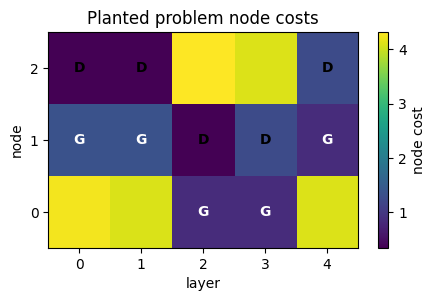

In [5]:
fig, ax = plt.subplots(figsize=(5.0, 2.8))
image = ax.imshow(problem.node_cost.T, origin="lower", aspect="auto")
ax.set_title("Planted problem node costs")
ax.set_xlabel("layer")
ax.set_ylabel("node")
ax.set_xticks(range(problem.L))
ax.set_yticks(range(problem.W))

for ell, v in gold_path:
    ax.text(ell, v, "G", ha="center", va="center", color="white", weight="bold")
for ell, v in decoy_path:
    ax.text(ell, v, "D", ha="center", va="center", color="black", weight="bold")

fig.colorbar(image, ax=ax, label="node cost")
plt.show()

The node-cost heatmap only shows the per-layer selection costs. It does not show transition costs, which is exactly where the decoy's late penalty is hidden. Source and sink are useful for graph algorithms, but the shared canvas for later DP, Soft-DP, and QA projections is only the visible `(layer, node)` grid.

## From Paths to Probabilities

Before adding Soft-DP or the feasible-subspace QA proxy, we can already ask: if a method gives us probabilities over complete paths, what notebook-visible quantities should we compute?

The utilities below are method-agnostic. Soft-DP will provide classical thermal path probabilities; QA will provide measurement probabilities from squared amplitudes. In both cases, entropy, expected energy, success probability, and layer-node marginals use the same definitions.

In [6]:
from pathspace_lab.math.observables import (
    cell_marginals,
    effective_num_paths,
    expected_energy,
    path_entropy,
    success_probability,
)

N = len(paths)
uniform_probs = np.ones(N) / N
optimal_path_probs = np.zeros(N)
optimal_path_probs[best_index] = 1.0

uniform_marginals = cell_marginals(problem, paths, uniform_probs)
optimal_marginals = cell_marginals(problem, paths, optimal_path_probs)

print("uniform entropy:", path_entropy(uniform_probs))
print("log N:", np.log(N))
print("uniform effective paths:", effective_num_paths(uniform_probs))
print("uniform expected energy:", expected_energy(uniform_probs, energies))
print("uniform success probability:", success_probability(uniform_probs, energies))
print("optimal expected energy:", expected_energy(optimal_path_probs, energies))
print("optimal success probability:", success_probability(optimal_path_probs, energies))
print("uniform marginal sum:", uniform_marginals.sum())
print("optimal marginal sum:", optimal_marginals.sum())

uniform entropy: 5.493061443340546
log N: 5.493061443340548
uniform effective paths: 242.9999999999993
uniform expected energy: 20.61289181762746
uniform success probability: 0.004115226337448558
optimal expected energy: 5.969999999999999
optimal success probability: 1.0
uniform marginal sum: 4.9999999999999964
optimal marginal sum: 5.0


In [7]:
observable_summary = pd.DataFrame(
    [
        {
            "distribution": "uniform",
            "entropy": path_entropy(uniform_probs),
            "effective paths": effective_num_paths(uniform_probs),
            "expected energy": expected_energy(uniform_probs, energies),
            "success probability": success_probability(uniform_probs, energies),
            "marginal sum": uniform_marginals.sum(),
        },
        {
            "distribution": "optimal path delta",
            "entropy": path_entropy(optimal_path_probs),
            "effective paths": effective_num_paths(optimal_path_probs),
            "expected energy": expected_energy(optimal_path_probs, energies),
            "success probability": success_probability(optimal_path_probs, energies),
            "marginal sum": optimal_marginals.sum(),
        },
    ]
)

observable_summary

,distribution,entropy,effective paths,expected energy,success probability,marginal sum
0,uniform,5.493061,243.0,20.612892,0.004115,5.0
1,optimal path delta,-0.000000,1.0,5.970000,1.000000,5.0


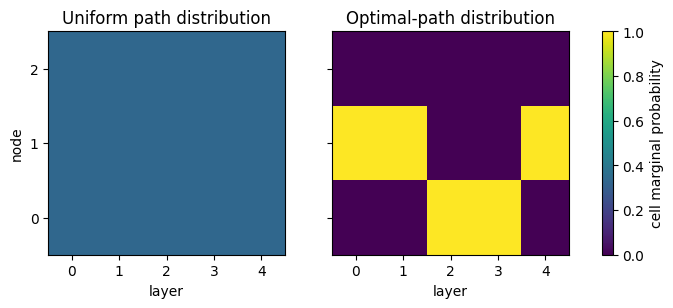

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(8.4, 2.9), sharey=True)

for ax, heat, title in [
    (axes[0], uniform_marginals, "Uniform path distribution"),
    (axes[1], optimal_marginals, "Optimal-path distribution"),
]:
    image = ax.imshow(heat.T, origin="lower", aspect="auto", vmin=0.0, vmax=1.0)
    ax.set_title(title)
    ax.set_xlabel("layer")
    ax.set_xticks(range(problem.L))
    ax.set_yticks(range(problem.W))

axes[0].set_ylabel("node")
fig.colorbar(image, ax=axes, label="cell marginal probability")
plt.show()

These heatmaps are projections of distributions over complete paths. The uniform distribution spreads each layer evenly across nodes, while the optimal-path delta distribution lights up exactly one cell per layer. Both sums equal `L`, because every feasible path visits one visible cell in every layer.

## The Data Contract

`Frame` and `SolverTrace` are the shared output shape for solvers and visualizers. A frame is one snapshot at a progress value. A trace is an ordered list of frames for one method on one problem.

The example below is deliberately dummy data. It checks the contract before any real solver exists.

toy 1 (2, 3)


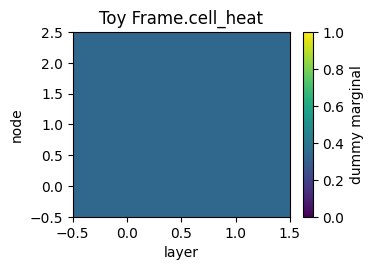

In [9]:
from pathspace_lab.utils.typing import Frame, SolverTrace

toy_heat = np.ones((2, 3)) / 3
frame = Frame(progress=0.0, label="toy", cell_heat=toy_heat)
trace = SolverTrace(method="toy", problem_name="toy", frames=[frame])

print(trace.method, len(trace.frames), trace.frames[0].cell_heat.shape)

fig, ax = plt.subplots(figsize=(3.5, 2.4))
image = ax.imshow(frame.cell_heat.T, origin="lower", aspect="auto", vmin=0.0, vmax=1.0)
ax.set_title("Toy Frame.cell_heat")
ax.set_xlabel("layer")
ax.set_ylabel("node")
fig.colorbar(image, ax=ax, label="dummy marginal")
plt.show()

## Hard DP as Deterministic Message Passing

Hard DP stores one scalar value per graph state: the best cost of any partial path reaching that state. It compresses histories by keeping only the current minimum and a backpointer.

The value heatmap below is not a probability heatmap. A lower value means a cheaper best partial path reaches that cell.

In [5]:
from pathspace_lab.solvers.hard_dp import solve_hard_dp, traceback_best_path

dp_trace = solve_hard_dp(problem)
dp_path = traceback_best_path(problem, dp_trace)
dp_energy = problem.path_energy(dp_path)
bruteforce_best = float(energies.min())

print("DP path:", dp_path)
print("DP energy:", dp_energy)
print("DP best value:", dp_trace.metadata["best_value"])
print("Brute force optimum:", bruteforce_best)
print("matches brute force:", np.isclose(dp_trace.metadata["best_value"], bruteforce_best))

DP path: ((0, 1), (1, 1), (2, 0), (3, 0), (4, 1))
DP energy: 5.969999999999999
DP best value: 5.970000000000001
Brute force optimum: 5.969999999999999
matches brute force: True


In [6]:
dp_summary = pd.DataFrame(
    [
        {
            "quantity": "DP best value",
            "value": dp_trace.metadata["best_value"],
            "note": "distance stored at the sink",
        },
        {
            "quantity": "traceback path energy",
            "value": dp_energy,
            "note": "energy of the recovered visible path",
        },
        {
            "quantity": "brute-force optimum",
            "value": bruteforce_best,
            "note": "minimum over enumerated complete paths",
        },
        {
            "quantity": "DP frames",
            "value": len(dp_trace.frames),
            "note": "one value snapshot per visible layer",
        },
    ]
)

dp_summary

,quantity,value,note
0,DP best value,5.97,distance stored at the sink
1,traceback path energy,5.97,energy of the recovered visible path
2,brute-force optimum,5.97,minimum over enumerated complete paths
3,DP frames,5.00,one value snapshot per visible layer


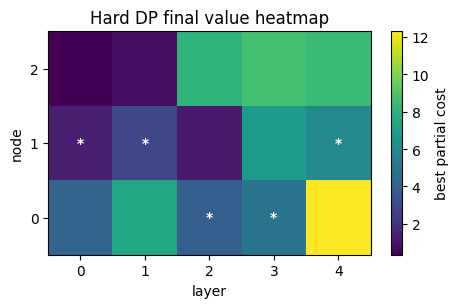

In [7]:
final_value_heat = dp_trace.frames[-1].value_heat

fig, ax = plt.subplots(figsize=(5.2, 2.9))
image = ax.imshow(final_value_heat.T, origin="lower", aspect="auto")
ax.set_title("Hard DP final value heatmap")
ax.set_xlabel("layer")
ax.set_ylabel("node")
ax.set_xticks(range(problem.L))
ax.set_yticks(range(problem.W))

for ell, v in dp_path:
    ax.text(ell, v, "*", ha="center", va="center", color="white", weight="bold")

fig.colorbar(image, ax=ax, label="best partial cost")
plt.show()

The traceback path energy matches the brute-force optimum, but the table DP built along the way is not a distribution over paths. It is a deterministic min-plus summary: each visible cell stores the cheapest partial history ending there.

## Soft-DP as Classical Thermal Condensation

Soft-DP is our classical thermal baseline. It assigns a Boltzmann probability to each complete feasible path:

\[
P_\beta(p)\propto e^{-\beta E(p)}.
\]

At `beta = 0`, every feasible path has equal probability. As beta grows, probability concentrates on low-energy complete paths. This is still a classical distribution over complete paths, not a quantum process.

In [ ]:
from pathspace_lab.solvers.soft_dp import solve_soft_dp

betas = np.linspace(0.0, 8.0, 81)
soft_trace = solve_soft_dp(problem, betas=betas, paths=paths)

first_soft = soft_trace.frames[0]
last_soft = soft_trace.frames[-1]
decoy_index = paths.index(decoy_path)

print("beta=0 prob sum:", first_soft.path_probs.sum())
print("beta=max prob sum:", last_soft.path_probs.sum())
print("beta=0 entropy:", first_soft.observables["entropy"])
print("beta=max success:", last_soft.observables["success_probability"])
print("beta=max expected energy:", last_soft.observables["expected_energy"])
print("optimal path probability at beta=max:", last_soft.path_probs[best_index])
print("decoy path probability at beta=max:", last_soft.path_probs[decoy_index])
print("beta=max marginal sum:", last_soft.cell_heat.sum())

In [ ]:
soft_summary = pd.DataFrame(
    [
        {
            "beta": frame.observables["beta"],
            "expected energy": frame.observables["expected_energy"],
            "residual energy": frame.observables["residual_energy"],
            "entropy": frame.observables["entropy"],
            "effective paths": frame.observables["effective_paths"],
            "success probability": frame.observables["success_probability"],
        }
        for frame in [first_soft, soft_trace.frames[len(soft_trace.frames) // 2], last_soft]
    ]
)

soft_summary

In [ ]:
snapshot_indices = [0, len(soft_trace.frames) // 2, len(soft_trace.frames) - 1]
fig, axes = plt.subplots(1, 3, figsize=(11.0, 3.0), sharey=True)

for ax, frame_index in zip(axes, snapshot_indices):
    frame = soft_trace.frames[frame_index]
    image = ax.imshow(frame.cell_heat.T, origin="lower", aspect="auto", vmin=0.0, vmax=1.0)
    ax.set_title(frame.label)
    ax.set_xlabel("layer")
    ax.set_xticks(range(problem.L))
    ax.set_yticks(range(problem.W))
    for ell, v in best_path:
        ax.text(ell, v, "*", ha="center", va="center", color="white", weight="bold")

axes[0].set_ylabel("node")
fig.colorbar(image, ax=axes, label="cell marginal probability")
plt.show()

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(9.0, 3.0))
beta_values = np.array([frame.observables["beta"] for frame in soft_trace.frames])
entropy_values = np.array([frame.observables["entropy"] for frame in soft_trace.frames])
success_values = np.array(
    [frame.observables["success_probability"] for frame in soft_trace.frames]
)

axes[0].plot(beta_values, entropy_values)
axes[0].set_title("Soft-DP entropy")
axes[0].set_xlabel("beta")
axes[0].set_ylabel("entropy")

axes[1].plot(beta_values, success_values)
axes[1].set_title("Soft-DP success probability")
axes[1].set_xlabel("beta")
axes[1].set_ylabel("probability on optimal paths")
axes[1].set_ylim(0.0, 1.05)

plt.show()

In [ ]:
top_indices = np.argsort(energies)[:5]
top_path_rows = []
for index in top_indices:
    label = "optimal" if index == best_index else "decoy" if index == decoy_index else "low energy"
    top_path_rows.append(
        {
            "label": label,
            "path": paths[int(index)],
            "energy": energies[int(index)],
            "P(beta=0)": first_soft.path_probs[int(index)],
            "P(beta=max)": last_soft.path_probs[int(index)],
        }
    )

if decoy_index not in set(int(i) for i in top_indices):
    top_path_rows.append(
        {
            "label": "decoy",
            "path": decoy_path,
            "energy": energies[decoy_index],
            "P(beta=0)": first_soft.path_probs[decoy_index],
            "P(beta=max)": last_soft.path_probs[decoy_index],
        }
    )

pd.DataFrame(top_path_rows)

The beta-zero marginal is broad because all complete paths are equally likely. At high beta, probability condenses around the low-energy path family, and the success probability rises. Unlike Hard DP, Soft-DP does not store a single best predecessor per state; it keeps a classical probability distribution over complete feasible paths and projects that distribution back onto the visible canvas.

## Feasible-Subspace QA

Pending implementation.

This section will build the feasible-subspace QA proxy: basis states are complete feasible paths, the driver ground state is uniform over feasible paths, and the problem Hamiltonian is diagonal in path energies.

## Same Projection, Different Dynamics

Pending implementation.

This section will compare Soft-DP and QA on the same layer-node canvas by progress and by matched entropy. The shared heatmap is a projection, not evidence that the hidden mechanisms are the same.

## Observable Dashboard

Pending implementation.

This section will track expected energy, residual energy, entropy, effective number of paths, success probability, and QA spectral gap when available.

## Flow vs Current

Pending implementation.

This section will contrast Soft-DP probability flow on the original DAG with QA probability current on the graph of complete paths. QA current must not be drawn as if it flows along the original problem edges.

## Summary, Limitations, and Roadmap

Pending implementation.

The MVP is a teaching model, not a quantum advantage claim, not a D-Wave hardware simulation, and not a generic QUBO transverse-field annealer. Future sections will keep those boundaries explicit while the notebook becomes more visual and more computationally complete.